# Tensor Basics

In [37]:
import tensorflow as tf   # Import the TensorFlow library

# Create tensors
scalar = tf.constant(7)   # A scalar tensor (single number)
vector = tf.constant([1, 2, 3])   # A 1D tensor (vector) with three elements
matrix = tf.constant([[1, 2], [3, 4]])  # A 2D tensor (matrix) with shape 2x2

print("Scalar:", scalar)   # Print the scalar tensor
print("Vector:", vector)   # Print the vector tensor
print("Matrix:", matrix)   # Print the matrix tensor

# Tensor operations
added = tf.add(vector, [4, 5, 6])
# Element-wise addition:
# [1+4, 2+5, 3+6] = [5, 7, 9]

multiplied = tf.multiply(matrix, 2)
# Element-wise multiplication with scalar 2:
# [[1*2, 2*2], [3*2, 4*2]] = [[2, 4], [6, 8]]

reshaped = tf.reshape(matrix, [4, 1])
# Reshape the 2x2 matrix into a 4x1 tensor

print("Added vector:", added.numpy())
# Convert added tensor to a NumPy array and print it

print("Multiplied matrix:", multiplied.numpy())
# Convert multiplied tensor to a NumPy array and print it

print("Reshaped matrix:", reshaped.numpy())
# Convert reshaped tensor to a NumPy array and print it


Scalar: tf.Tensor(7, shape=(), dtype=int32)
Vector: tf.Tensor([1 2 3], shape=(3,), dtype=int32)
Matrix: tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
Added vector: [5 7 9]
Multiplied matrix: [[2 4]
 [6 8]]
Reshaped matrix: [[1]
 [2]
 [3]
 [4]]


# Tensor Fundamentals — Shapes, Dtypes, and
# Gradients

In [38]:
import numpy as np    # Import NumPy for numerical operations

# Create a 2x2 integer Tensor
a = tf.constant([[1, 2], [3, 4]], dtype=tf.int32)
# 'a' is a tensor with shape (2, 2) and integer data type

# Create a 2x2 float Tensor
b = tf.constant([[0.5, 0.25], [0.75, 1.0]], dtype=tf.float32)
# 'b' is a tensor with shape (2, 2) containing floating-point numbers

# Create a Tensor from a NumPy array
c = tf.convert_to_tensor(np.arange(12).reshape(3, 4), dtype=tf.float32)
# np.arange(12) creates array [0,1,2,...,11]
# reshape(3, 4) turns it into a 3x4 matrix
# convert_to_tensor turns it into a TensorFlow tensor

print('Tensor a:', a)
# Prints the full tensor 'a'

print('Tensor b dtype:', b.dtype, 'shape:', b.shape)
# Prints the data type and shape of tensor 'b'

print('Tensor c shape & values:\n', c.numpy())
# Shows the NumPy representation of tensor 'c'
# c.numpy() converts the tensor into a normal NumPy array for easy viewing


Tensor a: tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
Tensor b dtype: <dtype: 'float32'> shape: (2, 2)
Tensor c shape & values:
 [[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]


In [39]:
import tensorflow as tf

# 2×2 tensor
x = tf.constant([[1., 2.], [3., 4.]])

# 2×1 tensor (will broadcast with x)
y = tf.constant([[5.], [6.]])

# Broadcasting: y expands to match x, then added
print('x + y (broadcasted):\n', x + y)

# Matrix multiplication (not element-wise)
print('Matrix multiplication (x @ x):\n', tf.matmul(x, x))



x + y (broadcasted):
 tf.Tensor(
[[ 6.  7.]
 [ 9. 10.]], shape=(2, 2), dtype=float32)
Matrix multiplication (x @ x):
 tf.Tensor(
[[ 7. 10.]
 [15. 22.]], shape=(2, 2), dtype=float32)


In [40]:

# Create a TensorFlow variable (required for gradient calculation)
x = tf.Variable([[1., 2.], [3., 4.]])

# Start recording operations for automatic differentiation
with tf.GradientTape() as tape:
    y = tf.reduce_sum(x ** 2)   # y = sum of squares of all elements in x

# Compute gradient dy/dx
dy_dx = tape.gradient(y, x)

# Print gradient values
print('dy/dx =', dy_dx.numpy())


dy/dx = [[2. 4.]
 [6. 8.]]


# Build MNIST Model using Keras Functional API

In [41]:
from tensorflow import keras
from tensorflow.keras import layers

# Load MNIST handwritten digit dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values (0-255 → 0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Input layer for 28×28 images
inputs = keras.Input(shape=(28, 28), name='input_layer')

# Flatten image to 1D vector
x = layers.Flatten()(inputs)

# First dense layer with ReLU activation
x = layers.Dense(128, activation='relu')(x)

# Dropout to reduce overfitting
x = layers.Dropout(0.3)(x)

# Second dense layer
x = layers.Dense(64, activation='relu')(x)

# Output layer (10 classes, softmax)
outputs = layers.Dense(10, activation='softmax', name='output_layer')(x)

# Build model using Functional API
model = keras.Model(inputs=inputs, outputs=outputs, name='mnist_functional_model')

# Print model structure
model.summary()


Model: "mnist_functional_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Compile and Train

In [42]:
# Compile the model with optimizer, loss function, and accuracy metric
model.compile(
    optimizer='adam',                         # Adam optimizer for fast training
    loss='sparse_categorical_crossentropy',   # Used for integer labels (0–9)
    metrics=['accuracy']                      # Track accuracy during training
)

# Train the model
history = model.fit(
    x_train,          # Training images
    y_train,          # Training labels
    epochs=5,         # Train for 5 passes over dataset
    batch_size=64,    # Train using batches of 64 samples
    validation_split=0.2   # 20% training data used for validation
)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7935 - loss: 0.6743 - val_accuracy: 0.9531 - val_loss: 0.1592
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9425 - loss: 0.1902 - val_accuracy: 0.9619 - val_loss: 0.1245
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9559 - loss: 0.1427 - val_accuracy: 0.9660 - val_loss: 0.1081
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9627 - loss: 0.1180 - val_accuracy: 0.9710 - val_loss: 0.0973
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9680 - loss: 0.1026 - val_accuracy: 0.9748 - val_loss: 0.0898


# Evaluate Model

In [43]:
# Evaluate the trained model on test dataset
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
# test_loss → loss value on test set
# test_acc  → accuracy on test set

# Print the test accuracy
print(f"Test accuracy: {test_acc:.4f}")  # Format to 4 decimal places



313/313 - 1s - 3ms/step - accuracy: 0.9757 - loss: 0.0776
Test accuracy: 0.9757


# Plot Training History


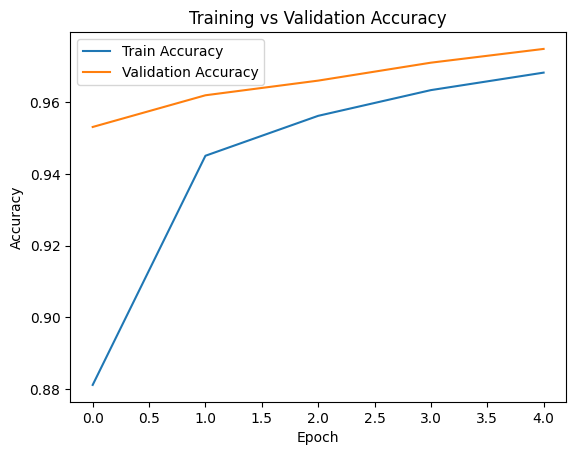

In [44]:
import matplotlib.pyplot as plt

# Plot training accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')

# Plot validation accuracy over epochs
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Add title and axis labels
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Show legend
plt.legend()

# Display the plot
plt.show()



# Save and Restore Models

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Save and Restore Models

In [30]:
# Save the model to Google Drive
save_path = '/content/drive/MyDrive/model.keras'
model.save(save_path)
print(f' Model saved successfully to {save_path}')

 Model saved successfully to /content/drive/MyDrive/model.keras


# Restore Models


In [31]:
load_path = '/content/drive/MyDrive/model.keras'
loaded_model = keras.models.load_model(load_path)
print(' Model loaded successfully from Drive.')

 Model loaded successfully from Drive.


# Model Checkpoints

In [45]:
import os
from tensorflow import keras

# Directory to save model checkpoints
save_dir = os.path.dirname(save_path)  # Get directory from save_path
checkpoint_path = os.path.join(save_dir, 'training_checkpoints', 'cp.weights.h5')
checkpoint_dir = os.path.dirname(checkpoint_path)  # Ensure checkpoint directory exists

# Create a ModelCheckpoint callback
cp_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,   # Filepath to save weights
    save_weights_only=True,     # Only save model weights (not full model)
    verbose=1,                  # Print a message when saving
    save_freq='epoch'           # Save checkpoint after every epoch
)

# Train the model with the checkpoint callback
# This will save weights after each epoch
model.fit(
    x_train,
    y_train,
    epochs=2,
    batch_size=64,
    callbacks=[cp_callback]
)


Epoch 1/2
927/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9693 - loss: 0.1000
Epoch 1: saving model to /content/drive/MyDrive/training_checkpoints/cp.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9693 - loss: 0.1000
Epoch 2/2
933/938 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9728 - loss: 0.0884
Epoch 2: saving model to /content/drive/MyDrive/training_checkpoints/cp.weights.h5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9728 - loss: 0.0884


In [46]:
import tensorflow as tf

# Find the latest checkpoint in the directory
latest_checkpoint = tf.train.latest_checkpoint(checkpoint_dir)
print('Latest checkpoint:', latest_checkpoint)

if latest_checkpoint:
    # Load weights from the latest checkpoint
    model.load_weights(latest_checkpoint)

    # Evaluate the restored model on test dataset
    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    # Print the restored model accuracy
    print(f"Restored checkpoint model accuracy: {acc:.4f}")
else:
    # If no checkpoint is found
    print("No checkpoint found in the specified directory.")


Latest checkpoint: None
No checkpoint found in the specified directory.


# Add Batch Normalization layers and compare accuracy

In [47]:
from tensorflow import keras
from tensorflow.keras import layers

# Build model with Batch Normalization
inputs = keras.Input(shape=(28,28))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)  # Added Batch Normalization
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.BatchNormalization()(x)  # Added Batch Normalization
outputs = layers.Dense(10, activation='softmax')(x)

model_bn = keras.Model(inputs=inputs, outputs=outputs)

# Compile the model
model_bn.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# Train the model
history_bn = model_bn.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate accuracy
loss, acc = model_bn.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy with Batch Normalization: {acc:.4f}")


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8170 - loss: 0.5988 - val_accuracy: 0.9549 - val_loss: 0.1538
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9388 - loss: 0.1962 - val_accuracy: 0.9625 - val_loss: 0.1240
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9536 - loss: 0.1524 - val_accuracy: 0.9672 - val_loss: 0.1077
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9623 - loss: 0.1227 - val_accuracy: 0.9736 - val_loss: 0.0908
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9645 - loss: 0.1097 - val_accuracy: 0.9714 - val_loss: 0.0906
Test accuracy with Batch Normalization: 0.9731


# Try using SGD and RMSprop optimizers

In [48]:
# Using SGD optimizer
model_sgd = keras.Model(inputs=inputs, outputs=outputs)
model_sgd.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history_sgd = model_sgd.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
loss_sgd, acc_sgd = model_sgd.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy with SGD: {acc_sgd:.4f}")

# Using RMSprop optimizer
model_rms = keras.Model(inputs=inputs, outputs=outputs)
model_rms.compile(optimizer='rmsprop',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
history_rms = model_rms.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)
loss_rms, acc_rms = model_rms.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy with RMSprop: {acc_rms:.4f}")


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9701 - loss: 0.0971 - val_accuracy: 0.9762 - val_loss: 0.0782
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9732 - loss: 0.0886 - val_accuracy: 0.9768 - val_loss: 0.0762
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9748 - loss: 0.0807 - val_accuracy: 0.9778 - val_loss: 0.0754
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9754 - loss: 0.0776 - val_accuracy: 0.9783 - val_loss: 0.0747
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9762 - loss: 0.0750 - val_accuracy: 0.9778 - val_loss: 0.0742
Test accuracy with SGD: 0.9792
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9710 - loss: 0.0945 - val_accuracy: 0.9767 - val_loss: 0.0835
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9743 - loss: 0.0832 - val_accuracy: 0.9745 - val_loss: 0.0886
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9720 - loss: 0

# Add a skip connection between layers

In [49]:
# Functional API with skip connection
inputs = keras.Input(shape=(28,28))
x = layers.Flatten()(inputs)
x1 = layers.Dense(128, activation='relu')(x)
x2 = layers.Dense(128, activation='relu')(x1)

# Skip connection: add output of first dense to second
x_skip = layers.Add()([x1, x2])
x_skip = layers.Dense(64, activation='relu')(x_skip)
outputs = layers.Dense(10, activation='softmax')(x_skip)

model_skip = keras.Model(inputs=inputs, outputs=outputs)

# Compile and train
model_skip.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_skip = model_skip.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

# Evaluate accuracy
loss_skip, acc_skip = model_skip.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy with skip connection: {acc_skip:.4f}")


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8560 - loss: 0.4991 - val_accuracy: 0.9478 - val_loss: 0.1768
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9639 - loss: 0.1199 - val_accuracy: 0.9632 - val_loss: 0.1244
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9771 - loss: 0.0747 - val_accuracy: 0.9681 - val_loss: 0.1047
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9823 - loss: 0.0546 - val_accuracy: 0.9711 - val_loss: 0.0973
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9882 - loss: 0.0373 - val_accuracy: 0.9720 - val_loss: 0.1016
Test accuracy with skip connection: 0.9740


# Save and restore only the weights

In [51]:
import os

# Save only weights
weights_path = "mnist_weights.weights.h5"
model_skip.save_weights(weights_path)  # Save weights only

# Create a new model with same architecture
new_model = keras.Model(inputs=inputs, outputs=outputs)
new_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Load saved weights
new_model.load_weights(weights_path)

# Evaluate restored model
loss_restored, acc_restored = new_model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy after restoring weights: {acc_restored:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test accuracy after restoring weights: 0.9740
